Loaded dataset: (10000, 21)
['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sleep Hours', 'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level', 'Heart Disease Status']

First rows:


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No



Missing values (top 20):


Alcohol Consumption     2586
Cholesterol Level         30
Sugar Consumption         30
Diabetes                  30
Age                       29
High LDL Cholesterol      26
CRP Level                 26
Triglyceride Level        26
High Blood Pressure       26
Sleep Hours               25
Low HDL Cholesterol       25
Smoking                   25
Exercise Habits           25
BMI                       22
Stress Level              22
Fasting Blood Sugar       22
Family Heart Disease      21
Homocysteine Level        20
Gender                    19
Blood Pressure            19
dtype: int64


Target distribution:


Heart Disease Status
0    8000
1    2000
Name: count, dtype: int64


Numeric cols (count=9): ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']
Categorical cols (count=11): ['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level']

Train/Test shapes: (8000, 20) (2000, 20)

Running GridSearchCV (this can take time)...
Best params: {'clf__C': 0.01, 'clf__class_weight': None}
Best CV ROC-AUC: 0.5134666558825939

Test metrics:
Accuracy: 0.8000
Precision: 0.0000
Recall: 0.0000
F1-score: 0.0000
ROC AUC: 0.4864

Classification report:
              precision    recall  f1-score   support

           0     0.8000    1.0000    0.8889      1600
           1     0.0000    0.0000    0.0000       400

    accuracy                         0.8000      2000
   macro avg     0.4000    0.5000    0.4444      2000
weighted avg     0.6400    0.8000   

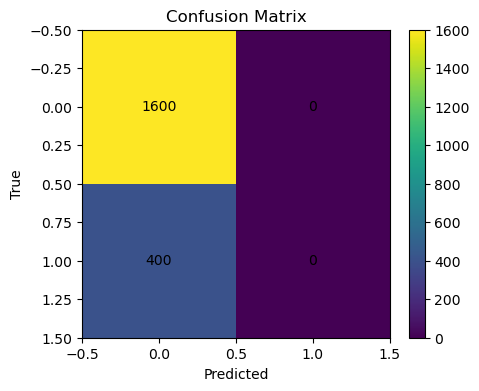

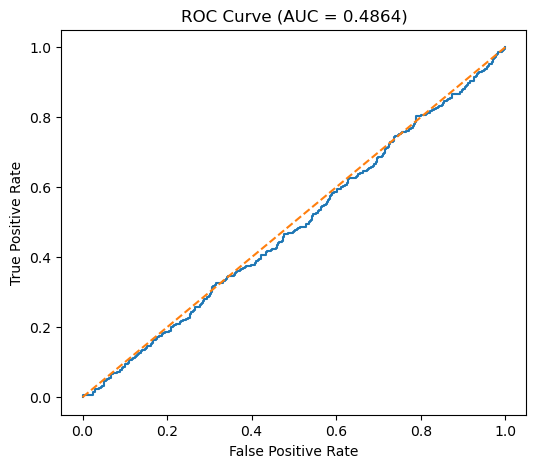


Top features by absolute coefficient (top 20):


,feature,coefficient,abs_coef
10,Gender_Male,-0.166025,0.166025
30,Stress Level_Low,-0.158998,0.158998
24,High LDL Cholesterol_No,-0.138199,0.138199
14,Smoking_No,-0.135940,0.135940
22,Low HDL Cholesterol_No,-0.125707,0.125707
17,Family Heart Disease_Yes,-0.125151,0.125151
21,High Blood Pressure_Yes,-0.122415,0.122415
18,Diabetes_No,-0.120385,0.120385
28,Alcohol Consumption_Medium,-0.118425,0.118425
19,Diabetes_Yes,-0.113237,0.113237



Saved summary to lr_heart_results_summary.csv


In [2]:
# ========= logistic_heart_pipeline.py =========
# Step-by-step pipeline to train & evaluate Logistic Regression
# Notes:
#  - Update file_path if your CSV is elsewhere.
#  - If memory issues appear, change onehot_sparse=False to True and solver to 'saga'.

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ------------ USER PARAMETERS ------------
file_path = "heart_disease.csv"   # change if needed
target_col = "Heart Disease Status"         # must match your CSV column name
onehot_sparse = False                       # set True if memory is tight (then solver='saga')
drop_missing_rate = 0.5                     # drop cols with >50% missing by default
test_size = 0.2
random_state = 42
# -----------------------------------------

# 1) Load data
df = pd.read_csv(file_path)
print("Loaded dataset:", df.shape)
print(df.columns.tolist())
print("\nFirst rows:")
display(df.head())

# 2) Missing values check
missing = df.isnull().sum()
print("\nMissing values (top 20):")
display(missing.sort_values(ascending=False).head(20))

# 3) Drop columns with too many missing values (optional)
cols_to_drop = missing[missing / len(df) > drop_missing_rate].index.tolist()
if cols_to_drop:
    print("\nDropping columns with >{:.0%} missing: {}".format(drop_missing_rate, cols_to_drop))
    df = df.drop(columns=cols_to_drop)
    print("New shape:", df.shape)

# 4) Target processing -> convert to binary 0/1
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found. Available columns: {df.columns.tolist()}")

y_raw = df[target_col].copy()
if y_raw.dtype == 'object' or y_raw.dtype.name == 'category':
    vals = sorted([str(x).lower() for x in y_raw.dropna().unique()])
    if set(vals) == set(['yes','no']):
        y = y_raw.map(lambda x: 1 if str(x).lower()=='yes' else 0).astype(int)
        mapping = {'Yes':1, 'No':0}
    else:
        # fallback: factorize (0/1)
        y, uniques = pd.factorize(y_raw)
        mapping = {v:i for i,v in enumerate(uniques)}
else:
    y = y_raw.values
    mapping = None

print("\nTarget distribution:")
display(pd.Series(y).value_counts())

# 5) Build X and detect column types
X = df.drop(columns=[target_col]).copy()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object','category','bool']).columns.tolist()
print("\nNumeric cols (count={}): {}".format(len(numeric_cols), numeric_cols[:10]))
print("Categorical cols (count={}): {}".format(len(categorical_cols), categorical_cols[:10]))

# 6) Drop constant columns (no predictive power)
nunique = X.nunique()
constant_cols = nunique[nunique <= 1].index.tolist()
if constant_cols:
    print("Dropping constant columns:", constant_cols)
    X = X.drop(columns=constant_cols)
    numeric_cols = [c for c in numeric_cols if c not in constant_cols]
    categorical_cols = [c for c in categorical_cols if c not in constant_cols]

# 7) Preprocessing pipelines
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=onehot_sparse))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# 8) Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size,
                                                    random_state=random_state, stratify=y)
print("\nTrain/Test shapes:", X_train.shape, X_test.shape)

# 9) Pipeline & model
solver = 'liblinear' if not onehot_sparse else 'saga'   # 'saga' supports sparse
clf = LogisticRegression(max_iter=1000, solver=solver)
pipeline = Pipeline([('preprocessor', preprocessor), ('clf', clf)])

# 10) Quick hyperparameter search (small grid to keep time reasonable)
param_grid = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__class_weight': [None, 'balanced']
}
grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='roc_auc', n_jobs=1)
print("\nRunning GridSearchCV (this can take time)...")
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

best_model = grid.best_estimator_

# 11) Predict & evaluate
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)

print("\nTest metrics:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

# 12) Confusion matrix (plot)
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)
plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.colorbar()
plt.show()

# 13) ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (AUC = {roc_auc:.4f})')
plt.show()

# 14) Feature interpretation (coefficients)
# extract feature names after the preprocessor
preprocessor.fit(X_train)
num_features = numeric_cols
cat_features = []
if categorical_cols:
    try:
        onehot = preprocessor.named_transformers_['cat'].named_steps['onehot']
        if hasattr(onehot, "get_feature_names_out"):
            cat_features = list(onehot.get_feature_names_out(categorical_cols))
        else:
            # older sklearn
            cat_features = list(onehot.get_feature_names(categorical_cols))
    except Exception as e:
        print("Could not extract one-hot names:", e)

feat_names = list(num_features) + cat_features
coefs = best_model.named_steps['clf'].coef_[0]
if len(coefs) == len(feat_names):
    coef_df = pd.DataFrame({'feature': feat_names, 'coefficient': coefs})
    coef_df['abs_coef'] = coef_df['coefficient'].abs()
    coef_df = coef_df.sort_values('abs_coef', ascending=False)
    print("\nTop features by absolute coefficient (top 20):")
    display(coef_df.head(20))
else:
    print("Feature/coefficient length mismatch - cannot show coefficients.")

# 15) Save results summary to a small CSV (optional)
summary = {
    'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': roc_auc,
    'best_params': grid.best_params_
}
pd.DataFrame([summary]).to_csv("lr_heart_results_summary.csv", index=False)
print("\nSaved summary to lr_heart_results_summary.csv")
# ============================================
